In [1]:
from pathlib import Path
import os

# Get current working directory
current_dir = Path(os.getcwd()).parent

npz_path_gc = current_dir / 'data' / '2-Data' / 'GoldCoast' / 'current_wind_20100101_20241231_GoaldCoast.npz'
stings_path_gc = current_dir / 'data'  / '2-Data' / 'GoldCoast' / 'goaldcoast_stings.csv'


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def create_sequential_dataset(stings_csv_path, env_npz_path, n_days, output_path='sequential_dataset.npz'):
    """
    Create a sequential dataset where each sample contains n days of environmental data
    with the target being the sting value on the final day.
    
    Parameters:
    -----------
    stings_csv_path : str
        Path to the stings CSV file
    env_npz_path : str
        Path to the environmental NPZ file
    n_days : int
        Number of days to include in each sequence
    output_path : str
        Path to save the output NPZ file
        
    Returns:
    --------
    dict : Information about the created dataset
    """
    
    # Load stings data
    print(f"Loading stings data from {stings_csv_path}...")
    stings_df = pd.read_csv(stings_csv_path)
    stings_df['time'] = pd.to_datetime(stings_df['time'], dayfirst=True)
    stings_df = stings_df.sort_values('time').reset_index(drop=True)
    
    # normalize column name lookup (case-insensitive)
    col_map = {col.lower(): col for col in stings_df.columns}
    sum_col = col_map.get('stings_sum')
    binary_col = col_map.get('stings_binary')
    if sum_col is None or binary_col is None:
        raise KeyError(f"Expected columns 'stings_sum' and 'stings_binary' (case-insensitive). Found: {list(stings_df.columns)}")
    
    # Load environmental data
    print(f"Loading environmental data from {env_npz_path}...")
    env_data = np.load(env_npz_path)
    UVTempSalt_UVTs = env_data['UVTempSalt_UVTs']  # Shape: (5479, 6, 15, 15)
    
    # Environmental data start date
    env_start_date = datetime(2010, 1, 1)
    
    print(f"\nEnvironmental data shape: {UVTempSalt_UVTs.shape}")
    print(f"Environmental data covers: {env_start_date} to {env_start_date + timedelta(days=UVTempSalt_UVTs.shape[0]-1)}")
    print(f"Number of sting records: {len(stings_df)}")
    print(f"Sequence length (n_days): {n_days}")
    
    # Storage for the new dataset
    sequences = []
    targets_sum = []
    targets_binary = []
    valid_dates = []
    
    skipped_count = 0
    
    # Process each sting record
    for idx, row in stings_df.iterrows():
        sting_date = row['time']
        
        # Calculate the start date for the sequence (n_days before sting_date, inclusive)
        # If n_days=7 and sting_date is 7/1/2024, we want 1/1/2024 to 7/1/2024
        start_date = sting_date - timedelta(days=n_days - 1)
        
        # Calculate indices in the environmental data
        start_idx = (start_date - env_start_date).days
        end_idx = (sting_date - env_start_date).days
        
        # Check if we have enough data
        if start_idx < 0 or end_idx >= UVTempSalt_UVTs.shape[0]:
            skipped_count += 1
            continue
        
        # Check if we have exactly n_days
        if (end_idx - start_idx + 1) != n_days:
            skipped_count += 1
            continue
        
        # Extract the sequence (n_days of environmental data)
        sequence = UVTempSalt_UVTs[start_idx:end_idx+1, :, :, :]  # Shape: (n_days, 6, 15, 15)
        
        # Store the sequence and targets
        sequences.append(sequence)
        targets_sum.append(row[sum_col])
        targets_binary.append(row[binary_col])
        valid_dates.append(sting_date.strftime('%Y-%m-%d'))
        
        if len(sequences) % 100 == 0:
            print(f"Processed {len(sequences)} valid sequences...")
    
    # Convert to numpy arrays
    sequences = np.array(sequences)  # Shape: (num_samples, n_days, 6, 15, 15)
    targets_sum = np.array(targets_sum)
    targets_binary = np.array(targets_binary)
    valid_dates = np.array(valid_dates)
    
    print(f"\n{'='*60}")
    print(f"Dataset Creation Summary:")
    print(f"{'='*60}")
    print(f"Total sting records: {len(stings_df)}")
    print(f"Skipped records (insufficient data): {skipped_count}")
    print(f"Valid sequences created: {len(sequences)}")
    print(f"\nOutput data shapes:")
    print(f"  Sequences: {sequences.shape} (num_samples, n_days, channels, height, width)")
    print(f"  Targets (sum): {targets_sum.shape}")
    print(f"  Targets (binary): {targets_binary.shape}")
    print(f"  Dates: {valid_dates.shape}")
    
    # Save to NPZ file
    print(f"\nSaving dataset to {output_path}...")
    np.savez_compressed(
        output_path,
        sequences=sequences,
        targets_sum=targets_sum,
        targets_binary=targets_binary,
        dates=valid_dates,
        n_days=n_days,
        crop_lon_min=env_data['crop_lon_min'],
        crop_lon_max=env_data['crop_lon_max'],
        crop_lat_min=env_data['crop_lat_min'],
        crop_lat_max=env_data['crop_lat_max']
    )
    
    print(f"\n✓ Dataset saved successfully!")
    
    # Return summary information
    return {
        'total_records': len(stings_df),
        'skipped': skipped_count,
        'valid_samples': len(sequences),
        'sequence_shape': sequences.shape,
        'output_path': output_path
    }

# Example usage:
# n_days = 7
for n_days in [5,7,10,12]:
    processed_data_path_gc = current_dir / 'data' / 'processed' / 'GoldCoast' / f'GoldCoast_{n_days}_days.npz'
    result = create_sequential_dataset(
        stings_csv_path=stings_path_gc,
        env_npz_path=npz_path_gc,
        n_days=n_days,
        output_path=processed_data_path_gc
    )


Loading stings data from c:\Users\VJ\Desktop\2025T3Group4\data\2-Data\GoldCoast\goaldcoast_stings.csv...
Loading environmental data from c:\Users\VJ\Desktop\2025T3Group4\data\2-Data\GoldCoast\current_wind_20100101_20241231_GoaldCoast.npz...

Environmental data shape: (5479, 6, 15, 15)
Environmental data covers: 2010-01-01 00:00:00 to 2024-12-31 00:00:00
Number of sting records: 797
Sequence length (n_days): 5
Processed 100 valid sequences...
Processed 200 valid sequences...
Processed 300 valid sequences...
Processed 400 valid sequences...
Processed 500 valid sequences...
Processed 600 valid sequences...
Processed 700 valid sequences...

Dataset Creation Summary:
Total sting records: 797
Skipped records (insufficient data): 54
Valid sequences created: 743

Output data shapes:
  Sequences: (743, 5, 6, 15, 15) (num_samples, n_days, channels, height, width)
  Targets (sum): (743,)
  Targets (binary): (743,)
  Dates: (743,)

Saving dataset to c:\Users\VJ\Desktop\2025T3Group4\data\processed\

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

# Get the processed data directory
processed_dir = current_dir / 'data' / 'processed' / 'GoldCoast'

# Find all NPZ files in the directory
npz_files = sorted(processed_dir.glob('*.npz'))

print(f"Found {len(npz_files)} dataset files in {processed_dir}")
print(f"\nCreating summary table for all datasets...\n")

# Store summary information for each dataset
summary_data = []

for npz_file in npz_files:
    print(f"Loading {npz_file.name}...")
    
    try:
        env_data = np.load(npz_file)
        
        # Load the sequential data
        sequences = env_data['sequences']
        targets_sum = env_data['targets_sum']
        targets_binary = env_data['targets_binary']
        dates = env_data['dates']
        n_days = int(env_data['n_days'])
        
        # Extract geographic bounds
        crop_lon_min = env_data['crop_lon_min']
        crop_lon_max = env_data['crop_lon_max']
        crop_lat_min = env_data['crop_lat_min']
        crop_lat_max = env_data['crop_lat_max']
        
        # Calculate statistics
        binary_dist = np.bincount(targets_binary.astype(int))
        class_0_count = binary_dist[0] if len(binary_dist) > 0 else 0
        class_1_count = binary_dist[1] if len(binary_dist) > 1 else 0
        total_samples = len(targets_binary)
        
        # Store summary
        summary_data.append({
            'Dataset': npz_file.name,
            'n_days': n_days,
            'Num_Samples': total_samples,
            'Sequence_Shape': f"{sequences.shape[1]}×{sequences.shape[2]}×{sequences.shape[3]}×{sequences.shape[4]}",
            'First_Date': str(dates[0]),
            'Last_Date': str(dates[-1]),
            'Stings_Sum_Min': targets_sum.min(),
            'Stings_Sum_Max': targets_sum.max(),
            'Class_0_Count': class_0_count,
            'Class_1_Count': class_1_count,
            'Class_0_Pct': f"{class_0_count/total_samples*100:.1f}%",
            'Class_1_Pct': f"{class_1_count/total_samples*100:.1f}%",
            'Lon_Range': f"[{crop_lon_min:.4f}, {crop_lon_max:.4f}]",
            'Lat_Range': f"[{crop_lat_min:.4f}, {crop_lat_max:.4f}]"
        })
        
    except Exception as e:
        print(f"  Error loading {npz_file.name}: {e}")
        summary_data.append({
            'Dataset': npz_file.name,
            'Error': str(e)
        })

# Create DataFrame
df_summary = pd.DataFrame(summary_data)

# Display the table
print(f"\n{'='*120}")
print("SUMMARY TABLE: All GoldCoast Processed Datasets")
print(f"{'='*120}\n")
print(df_summary.to_string(index=False))
print(f"\n{'='*120}")


Found 4 dataset files in c:\Users\VJ\Desktop\2025T3Group4\data\processed\GoldCoast

Creating summary table for all datasets...

Loading GoldCoast_10_days.npz...
Loading GoldCoast_12_days.npz...
Loading GoldCoast_6_days.npz...
Loading GoldCoast_8_days.npz...

SUMMARY TABLE: All GoldCoast Processed Datasets

              Dataset  n_days  Num_Samples Sequence_Shape First_Date  Last_Date  Stings_Sum_Min  Stings_Sum_Max  Class_0_Count  Class_1_Count Class_0_Pct Class_1_Pct            Lon_Range            Lat_Range
GoldCoast_10_days.npz      10          742     10×6×15×15 2010-01-16 2024-12-29               0            1704            544            198       73.3%       26.7% [153.4000, 154.8700] [-27.7530, -29.2000]
GoldCoast_12_days.npz      12          742     12×6×15×15 2010-01-16 2024-12-29               0            1704            544            198       73.3%       26.7% [153.4000, 154.8700] [-27.7530, -29.2000]
 GoldCoast_6_days.npz       6          743      6×6×15×15 2010-01-09

In [21]:
# import pandas as pd
# import numpy as np
# from datetime import datetime

# # Load the stings data
# stings_df = pd.read_csv(stings_path_gc)

# # Convert time column to datetime
# stings_df['time'] = pd.to_datetime(stings_df['time'], dayfirst=True)

# # Sort by date to ensure proper order
# stings_df = stings_df.sort_values('time').reset_index(drop=True)

# # Calculate gaps between consecutive dates
# stings_df['gap_days'] = stings_df['time'].diff().dt.days

# # Remove the first row (which will have NaN gap)
# gaps = stings_df['gap_days'].dropna()

# # Get all gaps greater than 1 day (actual missing data)
# missing_gaps = gaps[gaps > 1]

# print(f"Total number of records: {len(stings_df)}")
# print(f"Date range: {stings_df['time'].min()} to {stings_df['time'].max()}")
# print(f"Total number of gaps > 1 day: {len(missing_gaps)}")
# print(f"\n{'='*60}")

# # Count frequency of each gap size
# gap_counts = missing_gaps.value_counts().sort_index(ascending=False)

# print("\nGap sizes in DESCENDING order with their frequencies:")
# print(f"{'='*60}")
# print(f"{'Gap Size (days)':<20} {'Count':<10} {'Total Missing Days':<20}")
# print(f"{'-'*60}")

# for gap_size, count in gap_counts.items():
#     # Each gap of size N means N-1 missing days
#     missing_days = (gap_size - 1) * count
#     print(f"{int(gap_size):<20} {count:<10} {int(missing_days):<20}")

# print(f"\n{'='*60}")
# print(f"\nSummary Statistics:")
# print(f"  Largest gap: {int(missing_gaps.max())} days")
# print(f"  Smallest gap: {int(missing_gaps.min())} days")
# print(f"  Average gap size: {missing_gaps.mean():.2f} days")
# print(f"  Median gap size: {missing_gaps.median():.2f} days")

# # Calculate total missing days
# total_missing = sum((gap - 1) for gap in missing_gaps)
# print(f"  Total missing days: {int(total_missing)}")

# # Optional: Show details of the top 10 largest gaps with their date ranges
# print(f"\n{'='*60}")
# print("\nTop 10 Largest Gaps (with date ranges):")
# print(f"{'='*60}")

# # Find indices where gaps occur
# gap_indices = stings_df[stings_df['gap_days'] > 1].index

# # Create a list of gap details
# gap_details = []
# for idx in gap_indices:
#     gap_size = int(stings_df.loc[idx, 'gap_days'])
#     date_before = stings_df.loc[idx-1, 'time']
#     date_after = stings_df.loc[idx, 'time']
#     gap_details.append({
#         'gap_size': gap_size,
#         'from': date_before,
#         'to': date_after
#     })

# # Sort by gap size and show top 10
# gap_details_df = pd.DataFrame(gap_details)
# gap_details_df = gap_details_df.sort_values('gap_size', ascending=False).head(10)

# for i, row in gap_details_df.iterrows():
#     print(f"\n{row['gap_size']} days: {row['from'].date()} → {row['to'].date()}")


In [22]:
import numpy as np

print("\nLoading sequential dataset from NPZ file...")
env_data = np.load(processed_data_path_gc)

# Load the sequential data
sequences = env_data['sequences']  # Shape: (num_samples, n_days, 6, 15, 15)
targets_sum = env_data['targets_sum']  # Shape: (num_samples,)
targets_binary = env_data['targets_binary']  # Shape: (num_samples,)
dates = env_data['dates']  # Shape: (num_samples,)
n_days = int(env_data['n_days'])  # Sequence length

# Geographic bounds
crop_lon_min = env_data['crop_lon_min']
crop_lon_max = env_data['crop_lon_max']
crop_lat_min = env_data['crop_lat_min']
crop_lat_max = env_data['crop_lat_max']

print(f"\nSequential dataset loaded successfully!")
print(f"{'='*60}")
print(f"Data shape: {sequences.shape}")
print(f"  - Number of samples: {sequences.shape[0]}")
print(f"  - Sequence length (n_days): {sequences.shape[1]} (also stored as: {n_days})")
print(f"  - Channels: {sequences.shape[2]}")
print(f"  - Spatial grid: {sequences.shape[3]}x{sequences.shape[4]}")
print(f"\nTarget data:")
print(f"  - Targets (sum) shape: {targets_sum.shape}")
print(f"  - Targets (binary) shape: {targets_binary.shape}")
print(f"  - Dates shape: {dates.shape}")
print(f"\nGeographic bounds:")
print(f"  - Longitude: [{crop_lon_min:.4f}, {crop_lon_max:.4f}]")
print(f"  - Latitude: [{crop_lat_min:.4f}, {crop_lat_max:.4f}]")
print(f"\nDate range:")
print(f"  - First date: {dates[0]}")
print(f"  - Last date: {dates[-1]}")
print(f"\nTarget statistics:")
print(f"  - Stings_sum range: [{targets_sum.min()}, {targets_sum.max()}]")
print(f"  - Stings_binary distribution: {np.bincount(targets_binary.astype(int))}")
print(f"    (0: no bluebottles, 1: bluebottles present)")



Loading sequential dataset from NPZ file...

Sequential dataset loaded successfully!
Data shape: (742, 12, 6, 15, 15)
  - Number of samples: 742
  - Sequence length (n_days): 12 (also stored as: 12)
  - Channels: 6
  - Spatial grid: 15x15

Target data:
  - Targets (sum) shape: (742,)
  - Targets (binary) shape: (742,)
  - Dates shape: (742,)

Geographic bounds:
  - Longitude: [153.4000, 154.8700]
  - Latitude: [-27.7530, -29.2000]

Date range:
  - First date: 2010-01-16
  - Last date: 2024-12-29

Target statistics:
  - Stings_sum range: [0, 1704]
  - Stings_binary distribution: [544 198]
    (0: no bluebottles, 1: bluebottles present)


In [23]:
print(env_data.files)

['sequences', 'targets_sum', 'targets_binary', 'dates', 'n_days', 'crop_lon_min', 'crop_lon_max', 'crop_lat_min', 'crop_lat_max']


In [24]:
"""
==============================================================================
3D CNN TRAINING PIPELINE FOR BLUEBOTTLE STING PREDICTION
==============================================================================

This script contains:
1. Data loading and preprocessing (NaN handling, normalization)
2. Three lightweight 3D CNN architectures
3. Training pipeline with validation (TEMPORAL SPLIT - NO RANDOMIZATION)
4. Comprehensive evaluation and visualization
5. Model comparison and analysis

IMPORTANT: Uses temporal splitting to preserve time series order
- Training set: Earliest data
- Validation set: Middle period
- Test set: Most recent data

==============================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (confusion_matrix, classification_report, f1_score, 
                            accuracy_score, roc_auc_score, precision_score, 
                            recall_score, precision_recall_curve, auc)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
import warnings
warnings.filterwarnings('ignore')




# Set random seeds for reproducibility (model initialization only)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))} device(s)")
print("="*80 + "\n")



TensorFlow version: 2.10.1
GPU Available: 1 device(s)



In [25]:
# SECTION 1: DATA LOADING AND PREPROCESSING
# ==============================================================================

def load_and_preprocess_data(npz_path, location_name='Unknown'):
    """
    Load data from NPZ file and handle NaN values
    
    Parameters:
    -----------
    npz_path : str or Path
        Path to NPZ file containing sequences, targets_binary, dates
    location_name : str
        Name of location for printing
        
    Returns:
    --------
    sequences_normalized : ndarray
        Preprocessed sequences (samples, n_days, channels, H, W)
    targets_binary : ndarray
        Binary targets (samples,)
    dates : ndarray
        Date strings (samples,)
    """
    print(f"\n{'='*80}")
    print(f"LOADING {location_name.upper()} DATA")
    print(f"{'='*80}")
    print(f"File: {npz_path}")
    
    data = np.load(npz_path)
    
    sequences = data['sequences']  # Shape: (samples, n_days, channels, H, W)
    targets_binary = data['targets_binary']
    dates = data['dates']
    
    print(f"\\nOriginal shape: {sequences.shape}")
    print(f"  - Samples: {sequences.shape[0]}")
    print(f"  - Days: {sequences.shape[1]}")
    print(f"  - Channels: {sequences.shape[2]}")
    print(f"  - Spatial: {sequences.shape[3]}x{sequences.shape[4]}")
    print(f"\\nTargets shape: {targets_binary.shape}")
    print(f"Date range: {dates[0]} to {dates[-1]}")
    
    # Handle NaN values
    print(f"\n{'─'*80}")
    print("HANDLING NaN VALUES")
    print(f"{'─'*80}")
    nan_count_before = np.isnan(sequences).sum()
    print(f"NaN count before: {nan_count_before:,} ({nan_count_before/sequences.size*100:.2f}%)")
    
    # Replace NaN with 0 (land mask remains as 0)
    sequences_clean = np.nan_to_num(sequences, nan=0.0)
    
    nan_count_after = np.isnan(sequences_clean).sum()
    print(f"NaN count after: {nan_count_after:,}")
    print("✓ NaN values replaced with 0 (land mask)")
    
    # Normalize data (channel-wise normalization)
    print(f"\n{'─'*80}")
    print("NORMALIZING DATA (Channel-wise)")
    print(f"{'─'*80}")
    
    n_samples, n_days, n_channels, h, w = sequences_clean.shape
    sequences_normalized = np.zeros_like(sequences_clean)
    
    channel_names = ['U Current', 'V Current', 'Temperature', 'Salinity', 'U Wind', 'V Wind']
    
    for ch in range(n_channels):
        channel_data = sequences_clean[:, :, ch, :, :]
        
        # Get non-zero values for mean/std calculation (exclude land)
        non_zero_mask = channel_data != 0
        if non_zero_mask.any():
            mean_val = channel_data[non_zero_mask].mean()
            std_val = channel_data[non_zero_mask].std()
            
            if std_val > 0:
                sequences_normalized[:, :, ch, :, :] = np.where(
                    non_zero_mask,
                    (channel_data - mean_val) / std_val,
                    0
                )
            else:
                sequences_normalized[:, :, ch, :, :] = channel_data
        else:
            sequences_normalized[:, :, ch, :, :] = channel_data
        
        ch_name = channel_names[ch] if ch < len(channel_names) else f'Channel {ch+1}'
        print(f"  ✓ {ch_name:15s} - Mean: {mean_val:8.3f}, Std: {std_val:8.3f}")
    
    # Class distribution
    print(f"\n{'─'*80}")
    print("CLASS DISTRIBUTION")
    print(f"{'─'*80}")
    unique, counts = np.unique(targets_binary, return_counts=True)
    for u, c in zip(unique, counts):
        label = 'No Stings (0)' if u == 0 else 'Stings (1)'
        print(f"  {label:15s}: {c:4d} samples ({c/len(targets_binary)*100:5.1f}%)")
    
    print(f"\\n✓ Data loading and preprocessing complete!")
    
    return sequences_normalized, targets_binary, dates


In [26]:
def temporal_train_val_test_split(X, y, dates, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    """
    Split data temporally by FULL YEARS (chronologically) without randomization.
    This ensures no partial years are included in any split, preventing data leakage
    and maintaining realistic temporal boundaries.
    
    Parameters:
    -----------
    X : ndarray
        Features
    y : ndarray
        Labels
    dates : ndarray
        Date strings (will be converted to datetime)
    train_ratio : float
        Target proportion for training (default 0.70)
    val_ratio : float
        Target proportion for validation (default 0.15)
    test_ratio : float
        Target proportion for testing (default 0.15)
        
    Returns:
    --------
    X_train, X_val, X_test, y_train, y_val, y_test, dates_train, dates_val, dates_test
    """
    import pandas as pd
    import numpy as np
    
    # Ensure dates are pandas datetime
    dates_series = pd.Series(pd.to_datetime(dates))
    n_samples = len(X)
    
    # Get unique years in chronological order
    years = sorted(dates_series.dt.year.unique())
    n_years = len(years)
    
    print(f"\n{'─'*80}")
    print("TEMPORAL SPLIT BY FULL YEARS")
    print(f"{'─'*80}")
    print(f"Total samples: {n_samples}")
    print(f"Total years: {n_years} ({years[0]} to {years[-1]})")
    print(f"Target ratios: Train={train_ratio:.1%}, Val={val_ratio:.1%}, Test={test_ratio:.1%}")
    
    # Calculate number of years for each split (rounded to nearest integer)
    # We'll distribute years to get as close as possible to target ratios
    train_years_count = max(1, round(n_years * train_ratio))
    val_years_count = max(1, round(n_years * val_ratio))
    test_years_count = n_years - train_years_count - val_years_count
    
    # Ensure we have at least 1 year for each split
    if test_years_count < 1:
        test_years_count = 1
        val_years_count = max(1, n_years - train_years_count - test_years_count)
        train_years_count = n_years - val_years_count - test_years_count
    
    # Split years into groups
    train_years = years[:train_years_count]
    val_years = years[train_years_count:train_years_count + val_years_count]
    test_years = years[train_years_count + val_years_count:]
    
    print(f"\nYear distribution:")
    print(f"  Train years ({len(train_years)}): {train_years[0]} to {train_years[-1]}")
    print(f"  Val years ({len(val_years)}): {val_years[0]} to {val_years[-1]}")
    print(f"  Test years ({len(test_years)}): {test_years[0]} to {test_years[-1]}")
    
    # Create masks for each split based on years
    train_mask = dates_series.dt.year.isin(train_years)
    val_mask = dates_series.dt.year.isin(val_years)
    test_mask = dates_series.dt.year.isin(test_years)
    
    # Get indices for each split
    train_indices = np.where(train_mask)[0]
    val_indices = np.where(val_mask)[0]
    test_indices = np.where(test_mask)[0]
    
    # Split the data
    X_train = X[train_indices]
    y_train = y[train_indices]
    dates_train = dates[train_indices]
    
    X_val = X[val_indices]
    y_val = y[val_indices]
    dates_val = dates[val_indices]
    
    X_test = X[test_indices]
    y_test = y[test_indices]
    dates_test = dates[test_indices]
    
    # Print actual split statistics
    train_pct = len(X_train) / n_samples * 100
    val_pct = len(X_val) / n_samples * 100
    test_pct = len(X_test) / n_samples * 100
    
    print(f"\nActual split:")
    print(f"  Train: {len(X_train):4d} samples ({train_pct:5.1f}%) - {dates_train[0]} to {dates_train[-1]}")
    print(f"  Val:   {len(X_val):4d} samples ({val_pct:5.1f}%) - {dates_val[0]} to {dates_val[-1]}")
    print(f"  Test:  {len(X_test):4d} samples ({test_pct:5.1f}%) - {dates_test[0]} to {dates_test[-1]}")
    print(f"{'─'*80}\n")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, dates_train, dates_val, dates_test



In [27]:
# SECTION 2.5: CLASS IMBALANCE HANDLING
# ==============================================================================

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

def apply_smote(X_train, y_train, random_state=42):
    """
    Apply SMOTE (Synthetic Minority Over-sampling Technique) to balance classes
    
    Parameters:
    -----------
    X_train : ndarray
        Training features (samples, n_days, channels, H, W)
    y_train : ndarray
        Training labels
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    X_resampled : ndarray
        Resampled training features
    y_resampled : ndarray
        Resampled training labels
    """
    print(f"\n{'─'*80}")
    print("APPLYING SMOTE FOR CLASS BALANCING")
    print(f"{'─'*80}")
    
    # Get original class distribution
    unique, counts = np.unique(y_train, return_counts=True)
    print(f"Before SMOTE:")
    for u, c in zip(unique, counts):
        label = 'No Stings (0)' if u == 0 else 'Stings (1)'
        print(f"  {label:15s}: {c:4d} samples ({c/len(y_train)*100:5.1f}%)")
    
    # Reshape for SMOTE: (samples, features) where features = n_days * channels * H * W
    n_samples, n_days, n_channels, h, w = X_train.shape
    X_train_flat = X_train.reshape(n_samples, -1)
    
    # Apply SMOTE
    smote = SMOTE(random_state=random_state, k_neighbors=min(5, counts[1]-1) if counts[1] > 1 else 1)
    X_resampled_flat, y_resampled = smote.fit_resample(X_train_flat, y_train)
    
    # Reshape back to original shape
    X_resampled = X_resampled_flat.reshape(-1, n_days, n_channels, h, w)
    
    # Get new class distribution
    unique, counts = np.unique(y_resampled, return_counts=True)
    print(f"\nAfter SMOTE:")
    for u, c in zip(unique, counts):
        label = 'No Stings (0)' if u == 0 else 'Stings (1)'
        print(f"  {label:15s}: {c:4d} samples ({c/len(y_resampled)*100:5.1f}%)")
    print(f"  Total samples: {len(X_resampled)} (increased from {len(X_train)})")
    
    return X_resampled, y_resampled


def apply_random_undersampling(X_train, y_train, random_state=42):
    """
    Apply random undersampling to balance classes
    
    Parameters:
    -----------
    X_train : ndarray
        Training features (samples, n_days, channels, H, W)
    y_train : ndarray
        Training labels
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    X_resampled : ndarray
        Resampled training features
    y_resampled : ndarray
        Resampled training labels
    """
    print(f"\n{'─'*80}")
    print("APPLYING RANDOM UNDERSAMPLING FOR CLASS BALANCING")
    print(f"{'─'*80}")
    
    # Get original class distribution
    unique, counts = np.unique(y_train, return_counts=True)
    print(f"Before Random Undersampling:")
    for u, c in zip(unique, counts):
        label = 'No Stings (0)' if u == 0 else 'Stings (1)'
        print(f"  {label:15s}: {c:4d} samples ({c/len(y_train)*100:5.1f}%)")
    
    # Reshape for undersampling: (samples, features)
    n_samples, n_days, n_channels, h, w = X_train.shape
    X_train_flat = X_train.reshape(n_samples, -1)
    
    # Apply random undersampling
    undersampler = RandomUnderSampler(random_state=random_state)
    X_resampled_flat, y_resampled = undersampler.fit_resample(X_train_flat, y_train)
    
    # Reshape back to original shape
    X_resampled = X_resampled_flat.reshape(-1, n_days, n_channels, h, w)
    
    # Get new class distribution
    unique, counts = np.unique(y_resampled, return_counts=True)
    print(f"\nAfter Random Undersampling:")
    for u, c in zip(unique, counts):
        label = 'No Stings (0)' if u == 0 else 'Stings (1)'
        print(f"  {label:15s}: {c:4d} samples ({c/len(y_resampled)*100:5.1f}%)")
    print(f"  Total samples: {len(X_resampled)} (decreased from {len(X_train)})")
    
    return X_resampled, y_resampled


In [28]:
# SECTION 2: MODEL ARCHITECTURES
# ==============================================================================

def create_model_1_simple_3dcnn(input_shape, name="Simple3DCNN"):
    """
    Model 1: Simple 3D CNN with minimal layers
    
    Architecture:
    - 2 Conv3D blocks (16 → 32 filters)
    - Global Average Pooling (handles any spatial size)
    - Single dense layer
    
    Parameters: ~50K
    Best for: Baseline, fast training, less overfitting
    """
    model = models.Sequential(name=name)
    
    # First 3D Conv block
    model.add(layers.Conv3D(16, kernel_size=(2, 3, 3), activation='relu', 
                            padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(1, 2, 2)))
    model.add(layers.Dropout(0.2))
    
    # Second 3D Conv block
    model.add(layers.Conv3D(32, kernel_size=(2, 3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(1, 2, 2)))
    model.add(layers.Dropout(0.3))
    
    # Adaptive pooling to handle different spatial resolutions (15x15 or 12x12)
    model.add(layers.GlobalAveragePooling3D())
    
    # Dense layers
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model


def create_model_2_c3d_lite(input_shape, name="C3D_Lite"):
    """
    Model 2: C3D-inspired lightweight architecture
    
    Architecture:
    - 3 Conv3D blocks with 3x3x3 kernels (C3D style)
    - Progressive filters: 16 → 32 → 32
    - Global Average Pooling
    - Two dense layers
    
    Parameters: ~150K
    Best for: Better feature extraction, more capacity
    """
    model = models.Sequential(name=name)
    
    # Conv block 1
    model.add(layers.Conv3D(16, kernel_size=(3, 3, 3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(1, 2, 2)))
    
    # Conv block 2
    model.add(layers.Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))
    
    # Conv block 3
    model.add(layers.Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(2, 2, 2)))
    model.add(layers.Dropout(0.3))
    
    # Adaptive pooling
    model.add(layers.GlobalAveragePooling3D())
    
    # Dense layers
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model


def create_model_3_separable_3dcnn(input_shape, name="Separable3DCNN"):
    """
    Model 3: Separable 3D CNN with factorized convolutions
    
    Architecture:
    - Factorized (1,3,3) spatial + (3,1,1) temporal convolutions
    - Reduces parameters while maintaining capacity
    - 3 blocks: 16 → 32 → 64 filters
    - Global Average Pooling
    - Two dense layers
    
    Parameters: ~120K
    Best for: Parameter efficiency, separate spatial-temporal learning
    """
    inputs = layers.Input(shape=input_shape)
    
    # Block 1: Spatial then temporal convolution
    x = layers.Conv3D(16, kernel_size=(1, 3, 3), activation='relu', padding='same')(inputs)
    x = layers.Conv3D(16, kernel_size=(3, 1, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling3D(pool_size=(1, 2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 2: Spatial then temporal convolution
    x = layers.Conv3D(32, kernel_size=(1, 3, 3), activation='relu', padding='same')(x)
    x = layers.Conv3D(32, kernel_size=(3, 1, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling3D(pool_size=(1, 2, 2))(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 3
    x = layers.Conv3D(64, kernel_size=(1, 3, 3), activation='relu', padding='same')(x)
    x = layers.Conv3D(64, kernel_size=(2, 1, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Adaptive pooling
    x = layers.GlobalAveragePooling3D()(x)
    
    # Dense layers
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name=name)
    
    return model


def print_model_summary(model):
    """Print detailed model architecture and parameter count"""
    print(f"\n{'='*80}")
    print(f"MODEL: {model.name}")
    print(f"{'='*80}")
    model.summary()
    trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
    non_trainable = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
    print(f"\n{'─'*80}")
    print(f"Total parameters: {model.count_params():,}")
    print(f"  - Trainable: {trainable:,}")
    print(f"  - Non-trainable: {non_trainable:,}")
    print(f"{'='*80}")



In [29]:
# SECTION 3: TRAINING FUNCTIONS
# ==============================================================================
import tensorflow_addons as tfa
class TestSetEvaluationCallback(Callback):
    """Custom callback to evaluate model on test set after each epoch"""
    def __init__(self, X_test, y_test):
        super().__init__()
        self.X_test = X_test
        self.y_test = y_test
        self.test_metrics = {
            'test_loss': [],
            'test_accuracy': [],
            'test_auc': [],
            'test_precision': [],
            'test_recall': []
        }
    
    def on_epoch_end(self, epoch, logs=None):
        # Evaluate on test set
        test_results = self.model.evaluate(self.X_test, self.y_test, verbose=0)
        
        # Extract metrics (order: loss, accuracy, auc, precision, recall)
        metrics_names = self.model.metrics_names
        test_loss_idx = metrics_names.index('loss')
        test_acc_idx = metrics_names.index('accuracy')
        test_auc_idx = metrics_names.index('auc')
        test_precision_idx = metrics_names.index('precision')
        test_recall_idx = metrics_names.index('recall')
        
        self.test_metrics['test_loss'].append(test_results[test_loss_idx])
        self.test_metrics['test_accuracy'].append(test_results[test_acc_idx])
        self.test_metrics['test_auc'].append(test_results[test_auc_idx])
        self.test_metrics['test_precision'].append(test_results[test_precision_idx])
        self.test_metrics['test_recall'].append(test_results[test_recall_idx])
        
        # Add to logs for history
        logs = logs or {}
        logs['test_loss'] = test_results[test_loss_idx]
        logs['test_accuracy'] = test_results[test_acc_idx]
        logs['test_auc'] = test_results[test_auc_idx]
        logs['test_precision'] = test_results[test_precision_idx]
        logs['test_recall'] = test_results[test_recall_idx]


def train_model(model, X_train, y_train, X_val, y_val, X_test=None, y_test=None, 
                epochs=100, batch_size=16, use_early_stopping=True, method=None, learning_rate=0.001):
    """
    Train a model with callbacks and class weighting
    
    Parameters:
    -----------
    model : keras.Model
        Model to train
    X_train, y_train : ndarray
        Training data and labels
    X_val, y_val : ndarray
        Validation data and labels
    X_test, y_test : ndarray, optional
        Test data and labels (for evaluation during training)
    epochs : int
        Maximum number of epochs
    batch_size : int
        Batch size for training
    use_early_stopping : bool
        Whether to use early stopping callback (default: True)
        
    Returns:
    --------
    history : keras.History
        Training history object
    """
    print(f"\n{'='*80}")
    print(f"TRAINING: {model.name}")
    print(f"{'='*80}")
    
    # Compile model
    if method == 'FocalLoss':
        # Use focal loss for handling imbalance at loss level
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss=tfa.losses.SigmoidFocalCrossEntropy(
                alpha=0.25,  # Balance parameter
                gamma=2.0    # Focusing parameter (higher = more focus on hard examples)
            ),
            metrics=[
                'accuracy',
                keras.metrics.AUC(name='auc'),
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall')
            ]
        )
    else:
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                keras.metrics.AUC(name='auc'),
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall')
            ]
        )


    # Callbacks - conditionally add early stopping
    callbacks_list = []
    
    # Add test set evaluation callback if test data is provided
    if X_test is not None and y_test is not None:
        test_callback = TestSetEvaluationCallback(X_test, y_test)
        callbacks_list.append(test_callback)
    
    if use_early_stopping:
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        )
        callbacks_list.append(early_stopping)
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
    callbacks_list.append(reduce_lr)
    
    # Calculate class weights for imbalanced data
    class_counts = np.bincount(y_train.astype(int))
    total = len(y_train)
    # Avoid division by zero
    if len(class_counts) < 2:
        class_counts = np.array([class_counts[0], 0]) if len(class_counts)==1 else np.array([0,0])
    class_weight = {
        0: total / (2.0 * class_counts[0]) if class_counts[0]>0 else 1.0,
        1: total / (2.0 * class_counts[1]) if class_counts[1]>0 else 1.0
    }
    
    print(f"\nTraining Configuration:")
    print(f"  Training samples: {len(X_train)}")
    print(f"  Validation samples: {len(X_val)}")
    if X_test is not None:
        print(f"  Test samples: {len(X_test)}")
    print(f"  Batch size: {batch_size}")
    print(f"  Max epochs: {epochs}")
    print(f"  Class weights: {{0: {class_weight[0]:.3f}, 1: {class_weight[1]:.3f}}}")
    print(f"\nCallbacks:")
    if X_test is not None:
        print(f"  ✓ Test set evaluation (after each epoch)")
    if use_early_stopping:
        print(f"  ✓ Early stopping (patience=15)")
    print(f"  ✓ Learning rate reduction (patience=7)")
    print(f"\n{'─'*80}")
    print("Starting training...\n")
    
    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=callbacks_list,
        verbose=1
    )
    
    # Add test metrics to history if test callback was used
    if X_test is not None and y_test is not None:
        for metric_name, metric_values in test_callback.test_metrics.items():
            history.history[metric_name] = metric_values
    
    print(f"\n✓ Training complete for {model.name}!")
    print(f"  Final epoch: {len(history.history['loss'])}")
    try:
        print(f"  Best val_loss: {min(history.history['val_loss']):.4f}")
        print(f"  Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
    except Exception:
        pass
    if X_test is not None and 'test_accuracy' in history.history:
        print(f"  Best test_accuracy: {max(history.history['test_accuracy']):.4f}")
    
    return history



In [30]:
# SECTION 4: VISUALIZATION FUNCTIONS
# ==============================================================================

def plot_training_history(histories, model_names, save_path='training_history.png', include_test=True, date_range=None):
    """
    Plot training history for multiple models
    
    Creates a 2x3 grid showing:
    - Loss (train, val, test)
    - Accuracy (train, val, test)
    - AUC (train, val, test)
    - Precision (train, val, test)
    - Recall (train, val, test)
    - F1-Score (calculated from precision and recall)
    
    Parameters:
    -----------
    date_range : tuple
        Tuple of (start_date, end_date) to include in title (e.g., ("2010-01-01", "2024-12-31"))
    """
    n_metrics = 6
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']
    titles = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall', 'F1-Score']
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx]
        
        for hist_idx, (history, model_name) in enumerate(zip(histories, model_names)):
            epochs = range(1, len(history.history[metric]) + 1)
            
            # Training
            ax.plot(epochs, history.history[metric], 
                   label=f'{model_name} (Train)', 
                   linewidth=2.5, color=colors[hist_idx], alpha=0.8, linestyle='-')
            
            # Validation
            if f'val_{metric}' in history.history:
                ax.plot(epochs, history.history[f'val_{metric}'], 
                       label=f'{model_name} (Val)', 
                       linewidth=2.5, color=colors[hist_idx], alpha=0.7, linestyle='--')
            
            # Test
            if include_test and f'test_{metric}' in history.history:
                ax.plot(epochs, history.history[f'test_{metric}'], 
                       label=f'{model_name} (Test)', 
                       linewidth=2.5, color=colors[hist_idx], alpha=0.6, linestyle=':')
        
        ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
        ax.set_ylabel(title, fontsize=13, fontweight='bold')
        ax.set_title(f'{title} Comparison', fontsize=15, fontweight='bold', pad=15)
        ax.legend(loc='best', fontsize=9, framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # F1-Score (calculated from precision and recall)
    ax = axes[5]
    for hist_idx, (history, model_name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(history.history['precision']) + 1)
        
        # Calculate F1 from precision and recall
        train_prec = np.array(history.history['precision'])
        train_rec = np.array(history.history['recall'])
        train_f1 = 2 * (train_prec * train_rec) / (train_prec + train_rec + 1e-8)
        ax.plot(epochs, train_f1, label=f'{model_name} (Train)', 
               linewidth=2.5, color=colors[hist_idx], alpha=0.8, linestyle='-')
        
        if 'val_precision' in history.history and 'val_recall' in history.history:
            val_prec = np.array(history.history['val_precision'])
            val_rec = np.array(history.history['val_recall'])
            val_f1 = 2 * (val_prec * val_rec) / (val_prec + val_rec + 1e-8)
            ax.plot(epochs, val_f1, label=f'{model_name} (Val)', 
                   linewidth=2.5, color=colors[hist_idx], alpha=0.7, linestyle='--')
        
        if include_test and 'test_precision' in history.history and 'test_recall' in history.history:
            test_prec = np.array(history.history['test_precision'])
            test_rec = np.array(history.history['test_recall'])
            test_f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-8)
            ax.plot(epochs, test_f1, label=f'{model_name} (Test)', 
                   linewidth=2.5, color=colors[hist_idx], alpha=0.6, linestyle=':')
    
    ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
    ax.set_title('F1-Score Comparison', fontsize=15, fontweight='bold', pad=15)
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Title with date range if provided
    title_text = 'Training History - All Models (Train, Val, Test)'
    if date_range:
        title_text += f'\n{date_range[0]} to {date_range[1]}'
    
    plt.suptitle(title_text, fontsize=18, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Training history plot saved: {save_path}")
    plt.close()


def plot_precision_recall_curves(histories, model_names, X_train, y_train, X_test, y_test, 
                                  save_path='precision_recall_curves.png', date_range=None):
    """
    Plot precision-recall curves for train and test sets
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    # Train set
    ax = axes[0]
    for hist_idx, (history, model_name) in enumerate(zip(histories, model_names)):
        # Get predictions on train set
        y_train_pred_proba = model.predict(X_train, verbose=0)
        precision, recall, _ = precision_recall_curve(y_train, y_train_pred_proba)
        pr_auc = auc(recall, precision)
        
        ax.plot(recall, precision, label=f'{model_name} (AUC={pr_auc:.3f})', 
               linewidth=2.5, color=colors[hist_idx], alpha=0.8)
    
    ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
    ax.set_title('Precision-Recall Curve (Train Set)', fontsize=15, fontweight='bold', pad=15)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Test set
    ax = axes[1]
    for hist_idx, (history, model_name) in enumerate(zip(histories, model_names)):
        # Get the model from history (need to pass model instead)
        # For now, we'll need models passed separately - will update this
        pass
    
    # We need models, not just histories - update function signature
    title_text = 'Precision-Recall Curves'
    if date_range:
        title_text += f'\n{date_range[0]} to {date_range[1]}'
    
    plt.suptitle(title_text, fontsize=18, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Precision-recall curves saved: {save_path}")
    plt.close()


def plot_precision_recall_curves_from_models(models, model_names, X_train, y_train, X_test, y_test, 
                                              save_path='precision_recall_curves.png', date_range=None):
    """
    Plot precision-recall curves for train and test sets from models
    
    Parameters:
    -----------
    date_range : tuple
        Tuple of (start_date, end_date) to include in title (e.g., ("2010-01-01", "2024-12-31"))
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    # Train set
    ax = axes[0]
    for idx, (model, model_name) in enumerate(zip(models, model_names)):
        # Get predictions on train set
        y_train_pred_proba = model.predict(X_train, verbose=0)
        precision, recall, _ = precision_recall_curve(y_train, y_train_pred_proba)
        pr_auc = auc(recall, precision)
        
        ax.plot(recall, precision, label=f'{model_name} (AUC={pr_auc:.3f})', 
               linewidth=2.5, color=colors[idx], alpha=0.8)
    
    ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
    ax.set_title('Precision-Recall Curve (Train Set)', fontsize=15, fontweight='bold', pad=15)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Test set
    ax = axes[1]
    for idx, (model, model_name) in enumerate(zip(models, model_names)):
        # Get predictions on test set
        y_test_pred_proba = model.predict(X_test, verbose=0)
        precision, recall, _ = precision_recall_curve(y_test, y_test_pred_proba)
        pr_auc = auc(recall, precision)
        
        ax.plot(recall, precision, label=f'{model_name} (AUC={pr_auc:.3f})', 
               linewidth=2.5, color=colors[idx], alpha=0.8)
    
    ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
    ax.set_title('Precision-Recall Curve (Test Set)', fontsize=15, fontweight='bold', pad=15)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    title_text = 'Precision-Recall Curves'
    if date_range:
        title_text += f'\n{date_range[0]} to {date_range[1]}'
    
    plt.suptitle(title_text, fontsize=18, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Precision-recall curves saved: {save_path}")
    plt.close()

In [31]:
def plot_confusion_matrices(y_true_list, y_pred_list, model_names, 
                            save_path='confusion_matrices.png', date_range=None):
    """
    Plot beautiful confusion matrices for multiple models side-by-side
    
    Parameters:
    -----------
    date_range : tuple
        Tuple of (start_date, end_date) to include in title (e.g., ("2010-01-01", "2024-12-31"))
    """
    n_models = len(model_names)
    fig, axes = plt.subplots(1, n_models, figsize=(6.5*n_models, 5.5))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (y_true, y_pred, model_name) in enumerate(zip(y_true_list, y_pred_list, model_names)):
        cm = confusion_matrix(y_true, y_pred)
        
        # Calculate percentages
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        
        # Create annotations with counts and percentages
        annotations = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                count = cm[i, j]
                pct = cm_percent[i, j]
                annotations[i, j] = f'{count}\n({pct:.1f}%)'
        
        # Plot heatmap
        sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', 
                   cbar=True, ax=axes[idx], square=True, cbar_kws={'shrink': 0.8},
                   xticklabels=['No Stings (0)', 'Stings (1)'],
                   yticklabels=['No Stings (0)', 'Stings (1)'],
                   linewidths=2, linecolor='white',
                   annot_kws={'fontsize': 14, 'fontweight': 'bold'})
        
        axes[idx].set_title(f'{model_name}', fontsize=15, fontweight='bold', pad=15)
        axes[idx].set_ylabel('True Label', fontsize=13, fontweight='bold')
        axes[idx].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
        
        # Add metrics below
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        metrics_text = f'Accuracy: {acc:.3f}  |  F1-Score: {f1:.3f}'
        axes[idx].text(0.5, -0.18, metrics_text, 
                      transform=axes[idx].transAxes, ha='center',
                      fontsize=12, fontweight='bold',
                      bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.3))
    
    title_text = 'Confusion Matrices - Test Set'
    if date_range:
        title_text += f'\n{date_range[0]} to {date_range[1]}'
    else:
        title_text += ' (Most Recent Data)'
    
    plt.suptitle(title_text, fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Confusion matrices saved: {save_path}")
    plt.close()


def plot_model_comparison_bar(comparison_df, save_path='model_comparison_chart.png', date_range=None):
    """
    Create a bar chart comparing model metrics
    
    Parameters:
    -----------
    date_range : tuple
        Tuple of (start_date, end_date) to include in title (e.g., ("2010-01-01", "2024-12-31"))
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    models = comparison_df['Model'].values
    test_acc = comparison_df['Test Acc'].str.replace(',', '').astype(float).values
    test_f1 = comparison_df['Test F1'].str.replace(',', '').astype(float).values
    params = comparison_df['Parameters'].str.replace(',', '').astype(int).values / 1000
    
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    # Plot 1: Accuracy and F1-Score
    ax = axes[0]
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, test_acc, width, label='Accuracy', color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, test_f1, width, label='F1-Score', color=colors, alpha=0.5, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax.set_title('Test Set Performance', fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.0])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 2: Parameter count
    ax = axes[1]
    bars = ax.bar(models, params, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Parameters (thousands)', fontsize=13, fontweight='bold')
    ax.set_title('Model Complexity', fontsize=15, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, param in zip(bars, params):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
               f'{param:.1f}K', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    title_text = 'Model Comparison'
    if date_range:
        title_text += f'\n{date_range[0]} to {date_range[1]}'
    
    plt.suptitle(title_text, fontsize=18, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Model comparison chart saved: {save_path}")
    plt.close()


def plot_cross_dataset_comparison(all_results, metric='test_f1', save_path='cross_dataset_comparison.png'):
    """
    Create a grouped bar chart comparing models across all datasets
    
    Parameters:
    -----------
    all_results : list
        List of result dictionaries
    metric : str
        Metric to compare ('test_f1', 'test_accuracy', 'test_auc', etc.)
    save_path : str
        Path to save the figure
    """
    # Group results by dataset and model
    data_by_model_dataset = {}
    datasets = sorted(set([r['dataset'].replace('.npz', '').replace('GoldCoast_', '') for r in all_results]))
    models = sorted(set([r['model_name'] for r in all_results]))
    methods = sorted(set([r['method'] for r in all_results]))
    
    # Extract metric values
    metric_short = metric.replace('test_', '').upper()
    
    fig, axes = plt.subplots(len(methods), 1, figsize=(14, 5*len(methods)))
    if len(methods) == 1:
        axes = [axes]
    
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for method_idx, method in enumerate(methods):
        ax = axes[method_idx]
        
        # Filter results by method
        method_results = [r for r in all_results if r['method'] == method]
        
        # Create data structure for grouped bar chart
        x_pos = np.arange(len(datasets))
        width = 0.25
        
        for model_idx, model in enumerate(models):
            values = []
            for dataset in datasets:
                matching_results = [r for r in method_results 
                                  if r['model_name'] == model 
                                  and r['dataset'].replace('.npz', '').replace('GoldCoast_', '') == dataset]
                if matching_results:
                    metric_key = metric.replace('test_', '')
                    values.append(matching_results[0]['test_metrics'][metric_key])
                else:
                    values.append(0)
            
            ax.bar(x_pos + (model_idx - 1) * width, values, width, 
                   label=model, color=colors[model_idx], alpha=0.8, edgecolor='black', linewidth=1.5)
        
        ax.set_xlabel('Dataset (Days)', fontsize=12, fontweight='bold')
        ax.set_ylabel(f'{metric_short}', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric_short} Comparison by Dataset - {method}', fontsize=14, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(datasets, fontsize=11)
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, 1.0])
    
    plt.suptitle(f'Cross-Dataset Model Comparison - {metric_short}', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Cross-dataset comparison chart saved: {save_path}")
    plt.close()


In [32]:
# SECTION 5: EVALUATION AND COMPARISON
# ==============================================================================

def evaluate_model(model, X, y, set_name='Test'):
    """
    Evaluate a model and return comprehensive metrics
    
    Parameters:
    -----------
    model : keras.Model
        Model to evaluate
    X : ndarray
        Features
    y : ndarray
        True labels
    set_name : str
        Name of the dataset (for printing)
        
    Returns:
    --------
    metrics : dict
        Dictionary containing all metrics
    """
    # Predictions
    y_pred_prob = model.predict(X, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    
    # Calculate all metrics
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y, y_pred_prob)
    
    metrics = {
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob
    }
    
    print(f"\n{set_name} Set Performance:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  AUC:       {roc_auc:.4f}")
    
    return metrics


def evaluate_model_detailed(model, X_test, y_test, model_name):
    """
    Evaluate a single model and print detailed metrics
    """
    print(f"\n{'─'*80}")
    print(f"EVALUATING: {model_name}")
    print(f"{'─'*80}")
    
    # Get metrics
    metrics = evaluate_model(model, X_test, y_test, 'Test')
    
    y_pred = metrics['y_pred']
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                               target_names=['No Stings (0)', 'Stings (1)'],
                               digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix Breakdown:")
    print(f"  True Negatives (TN):  {tn:4d} - Correctly predicted no stings")
    print(f"  False Positives (FP): {fp:4d} - False alarms")
    print(f"  False Negatives (FN): {fn:4d} - Missed stings (CRITICAL)")
    print(f"  True Positives (TP):  {tp:4d} - Correctly predicted stings")
    
    return metrics


def create_comparison_table(models, histories, y_true_list, y_pred_list, model_names):
    """
    Create comprehensive comparison table
    """
    results = []
    
    for model, history, y_true, y_pred, model_name in zip(
            models, histories, y_true_list, y_pred_list, model_names):
        
        # Calculate metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        # Get final training metrics
        final_train_acc = history.history['accuracy'][-1]
        final_val_acc = history.history['val_accuracy'][-1]
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        
        # Get best validation metrics
        best_val_acc = max(history.history['val_accuracy'])
        best_epoch = np.argmax(history.history['val_accuracy']) + 1
        
        results.append({
            'Model': model_name,
            'Parameters': f"{model.count_params():,}",
            'Best Val Acc': f"{best_val_acc:.4f}",
            'Best Epoch': best_epoch,
            'Test Acc': f"{acc:.4f}",
            'Test F1': f"{f1:.4f}",
            'Final Train Loss': f"{final_train_loss:.4f}",
            'Final Val Loss': f"{final_val_loss:.4f}",
            'Epochs Trained': len(history.history['loss'])
        })
    
    df = pd.DataFrame(results)
    
    print(f"\n{'='*80}")
    print("MODEL COMPARISON TABLE")
    print(f"{'='*80}")
    print(df.to_string(index=False))
    print(f"{'='*80}\n")
    
    return df


In [33]:
"""
==============================================================================
COMPREHENSIVE COMPARISON TABLE CREATION
==============================================================================
"""

def create_comprehensive_comparison_table(all_results, save_path='model_comparison.csv'):
    """
    Create comprehensive comparison table with format:
    method, dataset, model, train(acc, f1, precision, recall, auc), test(acc, f1, precision, recall, auc)
    
    Parameters:
    -----------
    all_results : list
        List of result dictionaries, each containing:
        - method: str (e.g., 'None', 'SMOTE', 'RandomUndersampling')
        - dataset: str
        - model_name: str
        - train_metrics: dict with keys 'accuracy', 'f1', 'precision', 'recall', 'auc'
        - test_metrics: dict with keys 'accuracy', 'f1', 'precision', 'recall', 'auc'
    
    Returns:
    --------
    df : pandas.DataFrame
        Comparison table
    """
    rows = []
    
    for result in all_results:
        row = {
            'method': result['method'],
            'dataset': result['dataset'],
            'model': result['model_name'],
            'train_acc': f"{result['train_metrics']['accuracy']:.4f}",
            'train_f1': f"{result['train_metrics']['f1']:.4f}",
            'train_precision': f"{result['train_metrics']['precision']:.4f}",
            'train_recall': f"{result['train_metrics']['recall']:.4f}",
            'train_auc': f"{result['train_metrics']['auc']:.4f}",
            'test_acc': f"{result['test_metrics']['accuracy']:.4f}",
            'test_f1': f"{result['test_metrics']['f1']:.4f}",
            'test_precision': f"{result['test_metrics']['precision']:.4f}",
            'test_recall': f"{result['test_metrics']['recall']:.4f}",
            'test_auc': f"{result['test_metrics']['auc']:.4f}"
        }
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Format for display: combine train and test metrics
    df_display = df.copy()
    df_display['train_metrics'] = df_display.apply(
        lambda x: f"({x['train_acc']}, {x['train_f1']}, {x['train_precision']}, {x['train_recall']}, {x['train_auc']})", 
        axis=1
    )
    df_display['test_metrics'] = df_display.apply(
        lambda x: f"({x['test_acc']}, {x['test_f1']}, {x['test_precision']}, {x['test_recall']}, {x['test_auc']})", 
        axis=1
    )
    
    display_cols = ['method', 'dataset', 'model', 'train_metrics', 'test_metrics']
    df_final = df_display[display_cols]
    df_final.columns = ['Method', 'Dataset', 'Model', 'Train (acc, f1, prec, rec, auc)', 
                        'Test (acc, f1, prec, rec, auc)']
    
    print(f"\n{'='*180}")
    print("COMPREHENSIVE MODEL COMPARISON TABLE")
    print(f"{'='*180}\n")
    print(df_final.to_string(index=False))
    print(f"\n{'='*180}\n")
    
    # Save detailed CSV
    df.to_csv(save_path, index=False)
    print(f"✓ Saved detailed comparison table: {save_path}")
    
    return df_final, df


def create_dataset_model_metrics_table(all_results, save_path='dataset_model_metrics.csv'):
    """
    Create a detailed metrics table organized by Dataset + Model combination
    with separate columns for each metric
    
    Parameters:
    -----------
    all_results : list
        List of result dictionaries
    save_path : str
        Path to save the CSV file
        
    Returns:
    --------
    df_display : pandas.DataFrame
        Formatted display table
    df_detailed : pandas.DataFrame
        Detailed table for saving
    """
    rows = []
    
    for result in all_results:
        # Extract dataset info from filename
        dataset_name = result['dataset'].replace('.npz', '').replace('GoldCoast_', '')
        
        row = {
            'Dataset': dataset_name,
            'Model': result['model_name'],
            'Method': result['method'],
            'Test_Accuracy': f"{result['test_metrics']['accuracy']:.4f}",
            'Test_F1': f"{result['test_metrics']['f1']:.4f}",
            'Test_Precision': f"{result['test_metrics']['precision']:.4f}",
            'Test_Recall': f"{result['test_metrics']['recall']:.4f}",
            'Test_AUC': f"{result['test_metrics']['auc']:.4f}",
            'Train_Accuracy': f"{result['train_metrics']['accuracy']:.4f}",
            'Train_F1': f"{result['train_metrics']['f1']:.4f}",
            'Train_Precision': f"{result['train_metrics']['precision']:.4f}",
            'Train_Recall': f"{result['train_metrics']['recall']:.4f}",
            'Train_AUC': f"{result['train_metrics']['auc']:.4f}"
        }
        rows.append(row)
    
    df_detailed = pd.DataFrame(rows)
    
    # Sort by Dataset and Model for better readability
    df_sorted = df_detailed.sort_values(['Dataset', 'Model', 'Method']).reset_index(drop=True)
    
    print(f"\n{'='*220}")
    print("DETAILED METRICS TABLE BY DATASET + MODEL")
    print(f"{'='*220}\n")
    print(df_sorted.to_string(index=False))
    print(f"\n{'='*220}\n")
    
    # Save to CSV
    df_sorted.to_csv(save_path, index=False)
    print(f"✓ Saved detailed metrics table: {save_path}")
    
    return df_sorted, df_detailed


def create_best_models_summary(all_results, save_path='best_models_summary.csv'):
    """
    Create a summary table showing the best model for each dataset
    
    Parameters:
    -----------
    all_results : list
        List of result dictionaries
    save_path : str
        Path to save the CSV file
        
    Returns:
    --------
    df : pandas.DataFrame
        Summary table of best models per dataset
    """
    # Group by dataset
    datasets = sorted(set([r['dataset'] for r in all_results]))
    
    best_models = []
    
    for dataset in datasets:
        dataset_results = [r for r in all_results if r['dataset'] == dataset]
        
        # Find best by F1-score
        best = max(dataset_results, key=lambda x: x['test_metrics']['f1'])
        
        dataset_name = dataset.replace('.npz', '').replace('GoldCoast_', '')
        
        best_models.append({
            'Dataset': dataset_name,
            'Best_Model': best['model_name'],
            'Method': best['method'],
            'Test_Accuracy': f"{best['test_metrics']['accuracy']:.4f}",
            'Test_F1': f"{best['test_metrics']['f1']:.4f}",
            'Test_Precision': f"{best['test_metrics']['precision']:.4f}",
            'Test_Recall': f"{best['test_metrics']['recall']:.4f}",
            'Test_AUC': f"{best['test_metrics']['auc']:.4f}"
        })
    
    df = pd.DataFrame(best_models)
    
    print(f"\n{'='*140}")
    print("BEST MODEL SUMMARY BY DATASET")
    print(f"{'='*140}\n")
    print(df.to_string(index=False))
    print(f"\n{'='*140}\n")
    
    # Save to CSV
    df.to_csv(save_path, index=False)
    print(f"✓ Saved best models summary: {save_path}")
    
    return df

print("✓ Comparison table functions loaded!")


✓ Comparison table functions loaded!


In [35]:
"""
==============================================================================
TRAIN MODELS ON ALL DATASETS WITH SIMPLE TRAIN/VAL/TEST SPLIT
==============================================================================

This section:
1. Loads datasets from GoldCoast folder
2. Uses simple temporal train/val/test split (70/15/15)
3. Applies class imbalance methods: None, SMOTE, or RandomUndersampling
4. Trains all three model architectures
5. Evaluates on train and test sets with all metrics
6. Creates comprehensive comparison table
7. Generates training curves and precision-recall curves
"""

# Get all processed datasets
processed_dir = current_dir / 'data' / 'processed' / 'GoldCoast'
dataset_files = sorted(processed_dir.glob('GoldCoast_*.npz'))

print(f"\n{'='*80}")
print("MULTI-DATASET TRAINING WITH CLASS IMBALANCE METHODS")
print(f"{'='*80}")
print(f"\nFound {len(dataset_files)} datasets:")
for f in dataset_files:
    print(f"  - {f.name}")

# Training parameters
EPOCHS = 100
BATCH_SIZE = 16
USE_EARLY_STOPPING = False
OUTPUT_DIR = current_dir / 'notebooks' / 'outputs_multi_dataset'/'GoldCoast'
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Class imbalance methods to test
# Add FocalLoss as a training-time loss option (no resampling)
IMBALANCE_METHODS = ['FocalLoss','SMOTE', 'RandomUndersampling']

# Model creators
model_creators = {
    'Simple3DCNN': create_model_1_simple_3dcnn,
    'C3D_Lite': create_model_2_c3d_lite,
    'Separable3DCNN': create_model_3_separable_3dcnn
}

# Store all results for comparison table
all_results = []

# Train on each dataset
for dataset_file in dataset_files:
    print(f"\n{'='*80}")
    print(f"DATASET: {dataset_file.name}")
    print(f"{'='*80}")
    
    # Load and preprocess data
    X_all, y_all, dates_all = load_and_preprocess_data(dataset_file, dataset_file.stem)
    
    # Extract n_days from filename (if needed)
    try:
        n_days = int(dataset_file.stem.split('_')[-2])
    except Exception:
        n_days = None
    
    # Convert dates to pandas datetime for month filtering
    import pandas as pd
    dates_pd = pd.Series(pd.to_datetime(dates_all))
    
    # Create three dataset variants:
    #  - Original (unchanged)
    #  - First 3 months (Jan-Mar) and last 3 months (Oct-Dec)
    #  - First 2 months (Jan-Feb)
    variants = {}
    variants['original'] = (X_all, y_all, dates_all)
    
    # Jan-Mar and Oct-Dec - convert mask to numpy array with .to_numpy()
    mask_janmar_octdec = ((dates_pd.dt.month.isin([1,2,3])) | (dates_pd.dt.month.isin([10,11,12]))).to_numpy()
    if mask_janmar_octdec.sum() > 0:
        variants['janmar_octdec'] = (X_all[mask_janmar_octdec], y_all[mask_janmar_octdec], dates_all[mask_janmar_octdec])
    
    # Jan-Feb - convert mask to numpy array with .to_numpy()
    mask_janfeb = dates_pd.dt.month.isin([1,2]).to_numpy()
    if mask_janfeb.sum() > 0:
        variants['jan_feb'] = (X_all[mask_janfeb], y_all[mask_janfeb], dates_all[mask_janfeb])

    # Train each model with each imbalance method on each variant
    for variant_name, (X, y, dates) in variants.items():
        if len(X) == 0:
            print(f"\nSkipping variant '{variant_name}' - no samples")
            continue

        print(f"\n--- Variant: {variant_name} | Samples: {len(X)}")
        # Temporal split (70/15/15)
        X_train, X_val, X_test, y_train, y_val, y_test, dates_train, dates_val, dates_test = \
            temporal_train_val_test_split(X, y, dates, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15)

        print(f"Train: {len(X_train)} samples ({dates_train[0]} to {dates_train[-1]})")
        print(f"Val:   {len(X_val)} samples ({dates_val[0]} to {dates_val[-1]})")
        print(f"Test:  {len(X_test)} samples ({dates_test[0]} to {dates_test[-1]})")

        # Store date range for visualization
        date_range = (str(dates_test[0]), str(dates_test[-1]))

        for method in IMBALANCE_METHODS:
            print(f"\n{'#'*80}")
            print(f"CLASS IMBALANCE / LOSS METHOD: {method} | Variant: {variant_name}")
            print(f"{'#'*80}")
            
            # Apply class imbalance method (resampling methods modify X_train/y_train)
            X_train_processed = X_train.copy()
            y_train_processed = y_train.copy()

            if method == 'SMOTE':
                X_train_processed, y_train_processed = apply_smote(X_train, y_train)
            elif method == 'RandomUndersampling':
                X_train_processed, y_train_processed = apply_random_undersampling(X_train, y_train)
            else:
                print(f"\nUsing original training data (no resampling). If method=='FocalLoss', focal loss will be used at compile-time.")

            # Train each model architecture
            for model_name, model_creator in model_creators.items():
                print(f"\n{'='*80}")
                print(f"TRAINING: {model_name} with {method} | Variant: {variant_name}")
                print(f"{'='*80}")
                
                try:
                    # Create model
                    input_shape = X_train_processed.shape[1:]
                    model = model_creator(input_shape, name=f"{model_name}_{method}_{variant_name}")
                    
                    # Train model (with test set evaluation); if method == 'FocalLoss' we'll use focal loss inside train_model
                    history = train_model(
                        model, X_train_processed, y_train_processed, X_val, y_val,
                        X_test=X_test, y_test=y_test,
                        epochs=EPOCHS, batch_size=BATCH_SIZE, use_early_stopping=USE_EARLY_STOPPING, method=method, learning_rate=0.001
                    )
                    
                    # Evaluate on train and test sets
                    print(f"\n{'─'*80}")
                    print("EVALUATION")
                    print(f"{'─'*80}")
                    
                    train_metrics = evaluate_model(model, X_train_processed, y_train_processed, 'Train')
                    test_metrics = evaluate_model(model, X_test, y_test, 'Test')
                    
                    # Store results (store data references for precision-recall curves)
                    result = {
                        'method': method,
                        'dataset': dataset_file.name,
                        'model_name': model_name,
                        'variant': variant_name,
                        'date_range': date_range,
                        'train_metrics': {
                            'accuracy': train_metrics['accuracy'],
                            'f1': train_metrics['f1'],
                            'precision': train_metrics['precision'],
                            'recall': train_metrics['recall'],
                            'auc': train_metrics['auc']
                        },
                        'test_metrics': {
                            'accuracy': test_metrics['accuracy'],
                            'f1': test_metrics['f1'],
                            'precision': test_metrics['precision'],
                            'recall': test_metrics['recall'],
                            'auc': test_metrics['auc']
                        },
                        'model': model,
                        'history': history,
                        'X_train_processed': X_train_processed,  # Store for precision-recall curves
                        'y_train_processed': y_train_processed,
                        'X_test': X_test,
                        'y_test': y_test
                    }

                    all_results.append(result)

                    # Save model
                    model_save_path = OUTPUT_DIR / f"{dataset_file.stem}_{model_name}_{method}_{variant_name}_best.keras"
                    model.save(str(model_save_path))
                    print(f"\n✓ Saved model: {model_save_path}")
                    
                except Exception as e:
                    print(f"\n❌ Error training {model_name} with {method}: {e}")
                    import traceback
                    traceback.print_exc()

print(f"\n{'='*80}")
print("ALL TRAINING COMPLETE!")
print(f"{'='*80}")

# Create comprehensive comparison tables
print(f"\n{'='*80}")
print("CREATING COMPREHENSIVE COMPARISON TABLES")
print(f"{'='*80}")

comparison_table, comparison_df = create_comprehensive_comparison_table(
    all_results, 
    save_path=str(OUTPUT_DIR / 'model_comparison.csv')
)

metrics_table, metrics_df = create_dataset_model_metrics_table(
    all_results,
    save_path=str(OUTPUT_DIR / 'dataset_model_metrics.csv')
)

best_models_table = create_best_models_summary(
    all_results,
    save_path=str(OUTPUT_DIR / 'best_models_summary.csv')
)

# Plot confusion matrices for all models
print(f"\n{'='*80}")
print("GENERATING CONFUSION MATRICES FOR ALL MODELS")
print(f"{'='*80}")

# Group results by dataset and variant for confusion matrix plotting
datasets = sorted(set([r['dataset'] for r in all_results]))
variants = sorted(set([r['variant'] for r in all_results]))

for dataset in datasets:
    for variant in variants:
        dataset_variant_results = [r for r in all_results 
                                   if r['dataset'] == dataset and r['variant'] == variant]
        
        if not dataset_variant_results:
            continue
        
        # Get models, predictions, and true labels
        model_names_list = []
        y_true_list = []
        y_pred_list = []
        
        for result in dataset_variant_results:
            model_names_list.append(f"{result['model_name']}_{result['method']}")
            # Get test predictions
            y_test = result['y_test']
            y_pred_prob = result['model'].predict(result['X_test'], verbose=0)
            y_pred = (y_pred_prob > 0.5).astype(int).flatten()
            y_true_list.append(y_test)
            y_pred_list.append(y_pred)
        
        # Plot confusion matrices
        dataset_name_clean = dataset.replace('.npz', '').replace('GoldCoast_', '')
        cm_save_path = OUTPUT_DIR / f'{dataset_name_clean}_{variant}_confusion_matrices.png'
        date_range = dataset_variant_results[0]['date_range']
        
        plot_confusion_matrices(
            y_true_list, y_pred_list, model_names_list,
            save_path=str(cm_save_path),
            date_range=date_range
        )
        print(f"  ✓ Confusion matrices saved: {cm_save_path}")

print(f"\n{'='*80}")
print("CONFUSION MATRIX GENERATION COMPLETE!")
print(f"{'='*80}")



MULTI-DATASET TRAINING WITH CLASS IMBALANCE METHODS

Found 2 datasets:
  - GoldCoast_10_days.npz
  - GoldCoast_12_days.npz

DATASET: GoldCoast_10_days.npz

LOADING GOLDCOAST_10_DAYS DATA
File: c:\Users\VJ\Desktop\2025T3Group4\data\processed\GoldCoast\GoldCoast_10_days.npz
\nOriginal shape: (742, 10, 6, 15, 15)
  - Samples: 742
  - Days: 10
  - Channels: 6
  - Spatial: 15x15
\nTargets shape: (742,)
Date range: 2010-01-16 to 2024-12-29

────────────────────────────────────────────────────────────────────────────────
HANDLING NaN VALUES
────────────────────────────────────────────────────────────────────────────────
NaN count before: 1,127,840 (11.26%)
NaN count after: 0
✓ NaN values replaced with 0 (land mask)

────────────────────────────────────────────────────────────────────────────────
NORMALIZING DATA (Channel-wise)
────────────────────────────────────────────────────────────────────────────────
  ✓ U Current       - Mean:   -0.015, Std:    0.182
  ✓ V Current       - Mean:   -0.4


GENERATING VISUALIZATIONS FOR: GoldCoast_10_days.npz


IndexError: list index out of range

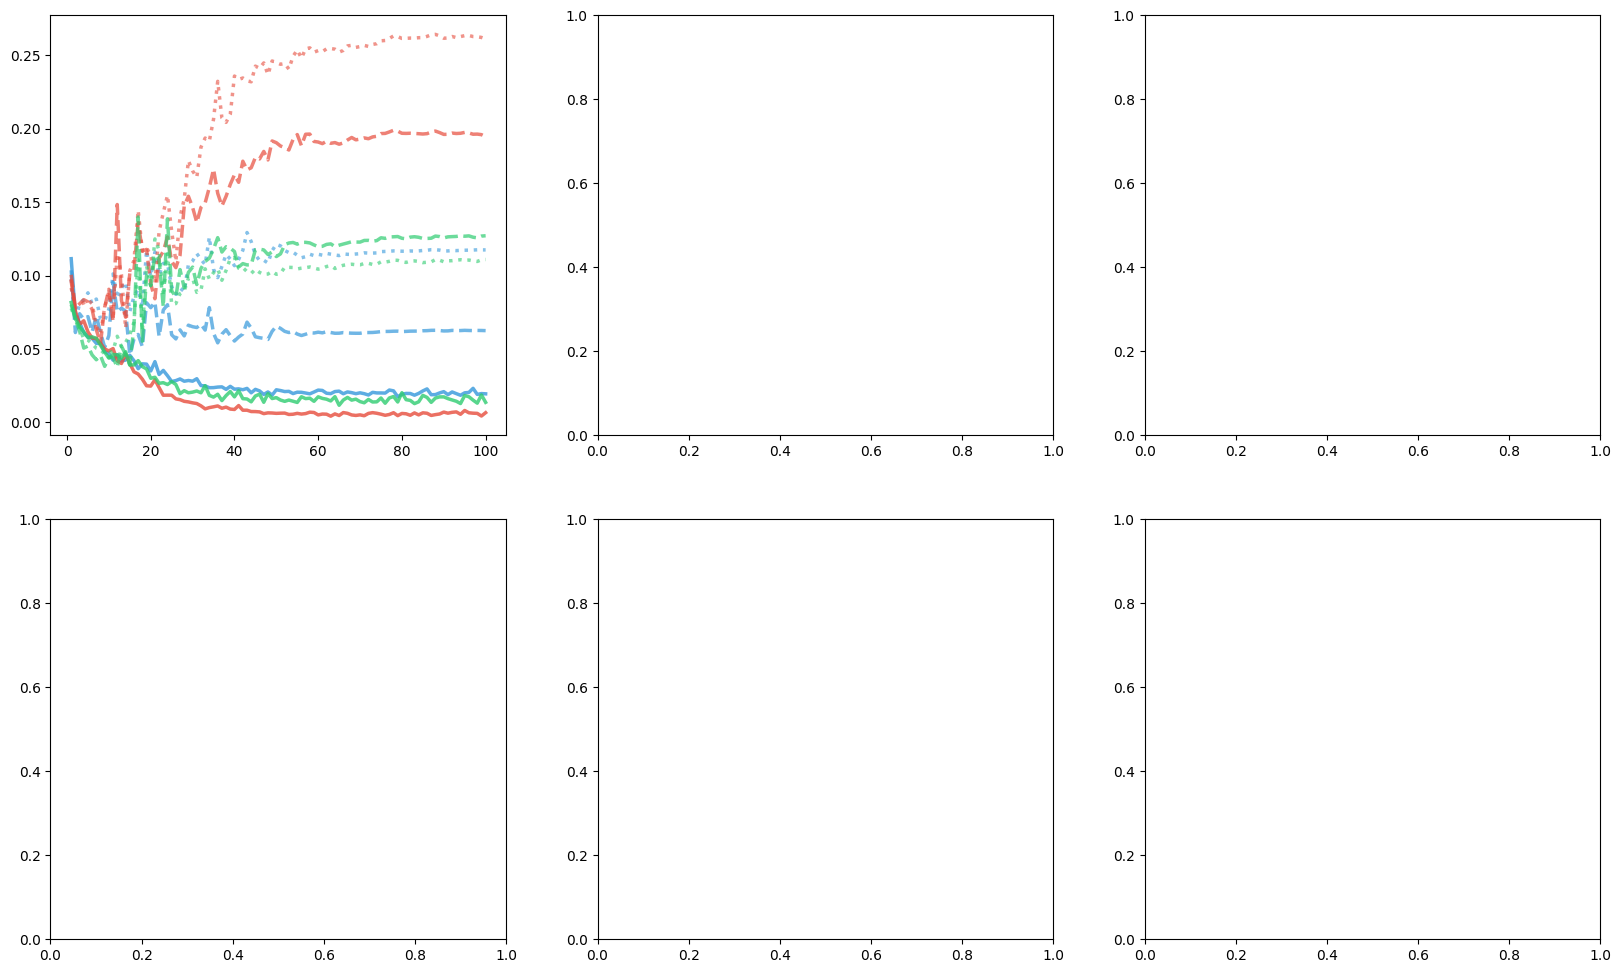

In [36]:
"""
==============================================================================
GENERATE TRAINING CURVES AND PRECISION-RECALL CURVES WITH DATE RANGES
==============================================================================
"""

# Group results by dataset for visualization
datasets = sorted(set([r['dataset'] for r in all_results]))

for dataset in datasets:
    dataset_results = [r for r in all_results if r['dataset'] == dataset]
    
    print(f"\n{'='*80}")
    print(f"GENERATING VISUALIZATIONS FOR: {dataset}")
    print(f"{'='*80}")
    
    # Group by method for comparison
    for method in IMBALANCE_METHODS:
        method_results = [r for r in dataset_results if r['method'] == method]
        
        if not method_results:
            continue
        
        # Get models and histories for this method
        models = [r['model'] for r in method_results]
        histories = [r['history'] for r in method_results]
        model_names = [r['model_name'] for r in method_results]
        
        # Get date range from first result
        date_range = method_results[0]['date_range']
        
        # Get train and test data from first result (same for all models with same method)
        first_result = method_results[0]
        X_train_processed = first_result['X_train_processed']
        y_train_processed = first_result['y_train_processed']
        X_test = first_result['X_test']
        y_test = first_result['y_test']
        
        # Plot training history
        history_save_path = OUTPUT_DIR / f"{dataset.replace('.npz', '')}_{method}_training_history.png"
        plot_training_history(histories, model_names, save_path=str(history_save_path), 
                            include_test=True, date_range=date_range)
        print(f"  ✓ Training history saved: {history_save_path}")
        
        # Plot precision-recall curves
        pr_curve_save_path = OUTPUT_DIR / f"{dataset.replace('.npz', '')}_{method}_precision_recall_curves.png"
        plot_precision_recall_curves_from_models(
            models, model_names, 
            X_train_processed, y_train_processed,
            X_test, y_test,
            save_path=str(pr_curve_save_path),
            date_range=date_range
        )
        print(f"  ✓ Precision-recall curves saved: {pr_curve_save_path}")

# Create cross-dataset comparisons
print(f"\n{'='*80}")
print("GENERATING CROSS-DATASET COMPARISON CHARTS")
print(f"{'='*80}")

# F1-Score comparison across all datasets
f1_comparison_path = OUTPUT_DIR / 'cross_dataset_f1_comparison.png'
plot_cross_dataset_comparison(all_results, metric='test_f1', save_path=str(f1_comparison_path))
print(f"  ✓ F1-Score comparison saved: {f1_comparison_path}")

# Accuracy comparison across all datasets
accuracy_comparison_path = OUTPUT_DIR / 'cross_dataset_accuracy_comparison.png'
plot_cross_dataset_comparison(all_results, metric='test_accuracy', save_path=str(accuracy_comparison_path))
print(f"  ✓ Accuracy comparison saved: {accuracy_comparison_path}")

# AUC comparison across all datasets
auc_comparison_path = OUTPUT_DIR / 'cross_dataset_auc_comparison.png'
plot_cross_dataset_comparison(all_results, metric='test_auc', save_path=str(auc_comparison_path))
print(f"  ✓ AUC comparison saved: {auc_comparison_path}")

print(f"\n{'='*80}")
print("VISUALIZATION GENERATION COMPLETE!")
print(f"{'='*80}")
print(f"All visualizations saved to: {OUTPUT_DIR}")


In [ ]:
"""
==============================================================================
SUMMARY AND BEST MODEL SELECTION
==============================================================================
"""

# Find best overall model-method-dataset combination
if len(all_results) > 0:
    best_result = max(all_results, key=lambda x: x['test_metrics']['f1'])
    
    print(f"\n{'='*80}")
    print("BEST MODEL-METHOD-DATASET COMBINATION (BY F1-SCORE)")
    print(f"{'='*80}")
    print(f"\n🏆 Best Combination:")
    print(f"   Dataset: {best_result['dataset']}")
    print(f"   Date Range: {best_result['date_range'][0]} to {best_result['date_range'][1]}")
    print(f"   Model: {best_result['model_name']}")
    print(f"   Method: {best_result['method']}")
    print(f"\n   Test Performance:")
    print(f"     F1-Score:  {best_result['test_metrics']['f1']:.4f}")
    print(f"     Accuracy:  {best_result['test_metrics']['accuracy']:.4f}")
    print(f"     Precision: {best_result['test_metrics']['precision']:.4f}")
    print(f"     Recall:    {best_result['test_metrics']['recall']:.4f}")
    print(f"     AUC:       {best_result['test_metrics']['auc']:.4f}")
    print(f"\n   Train Performance:")
    print(f"     F1-Score:  {best_result['train_metrics']['f1']:.4f}")
    print(f"     Accuracy:  {best_result['train_metrics']['accuracy']:.4f}")
    print(f"     Precision: {best_result['train_metrics']['precision']:.4f}")
    print(f"     Recall:    {best_result['train_metrics']['recall']:.4f}")
    print(f"     AUC:       {best_result['train_metrics']['auc']:.4f}")
    print(f"{'='*80}\n")
    
    # Show top 5 models by F1-score
    print(f"\n{'='*80}")
    print("TOP 5 MODELS BY TEST F1-SCORE")
    print(f"{'='*80}\n")
    
    top_5 = sorted(all_results, key=lambda x: x['test_metrics']['f1'], reverse=True)[:5]
    for idx, result in enumerate(top_5, 1):
        print(f"{idx}. {result['model_name']} + {result['method']} ({result['dataset'].replace('.npz', '')})")
        print(f"   Date Range: {result['date_range'][0]} to {result['date_range'][1]}")
        print(f"   Test F1: {result['test_metrics']['f1']:.4f} | Acc: {result['test_metrics']['accuracy']:.4f} | AUC: {result['test_metrics']['auc']:.4f}")
        print()
else:
    print("\n❌ No training results found!")

print(f"{'='*80}")
print("ANALYSIS COMPLETE - OUTPUTS SAVED TO:")
print(f"   {OUTPUT_DIR}")
print(f"\nGenerated Files:")
print(f"   📊 METRICS TABLES:")
print(f"     - model_comparison.csv (comprehensive comparison)")
print(f"     - dataset_model_metrics.csv (detailed metrics by dataset+model)")
print(f"     - best_models_summary.csv (best model per dataset)")
print(f"\n   📈 TRAINING CURVES:")
print(f"     - *_training_history.png (per dataset and method)")
print(f"\n   📉 PRECISION-RECALL CURVES:")
print(f"     - *_precision_recall_curves.png (per dataset and method)")
print(f"\n   📊 CROSS-DATASET COMPARISONS:")
print(f"     - cross_dataset_f1_comparison.png")
print(f"     - cross_dataset_accuracy_comparison.png")
print(f"     - cross_dataset_auc_comparison.png")
print(f"\n   🤖 SAVED MODELS:")
print(f"     - *.keras files for each model-dataset-method combination")
print(f"{'='*80}\n")
